# SIR epidemic simulation with Euler's method

COVID-19 spread in Karaganda, Kazakhstan, modelled with the SIR equations and solved numerically with a hand-written Euler integrator.

## The solver and the baseline run

`b` is the infection rate and `k` the removal rate. Baseline `b = 0.17` is the mean transmission rate estimated for Karaganda by Koichubekov et al. (2023).

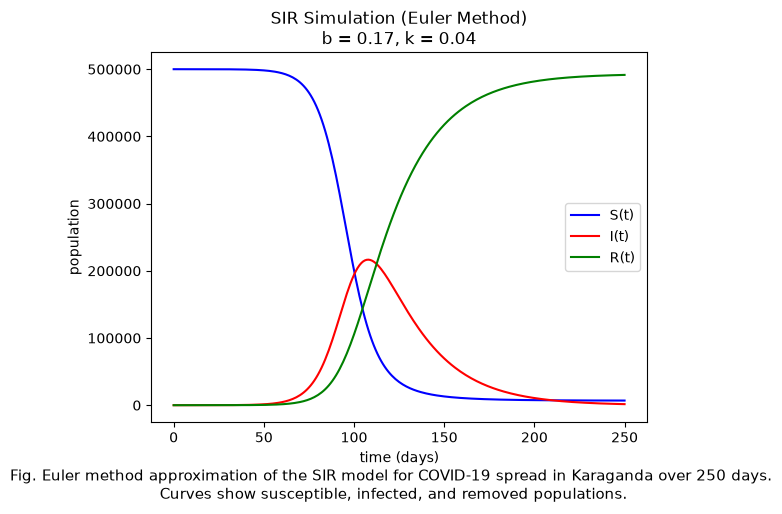

In [1]:
# Define a function to implement Euler's method
import numpy as np
import matplotlib.pyplot as plt

def SIR_Euler(b,k,initial_conds, duration=90):
    t0 = 0 # starting time
    t_end = duration # defining the simulation length (days)
    h = 1 # defining the step size
    steps = int((t_end - t0)/h + 1) # number of euler steps

    # variables:
    t = np.linspace(t0, t_end, steps) # storing t values (time)
    S, I, R = np.zeros(steps), np.zeros(steps), np.zeros(steps) # arrays for storing SIR values

    S[0], I[0], R[0] = initial_conds[0], initial_conds[1], initial_conds[2] # set initial conditions
    N = S[0] + I[0] + R[0] # total population

    # Euler method loop
    for n in range(steps-1):
        # SIR differential equations
        dS = -b * S[n] * I[n] / N
        dI = b * S[n] * I[n] / N - k * I[n]
        dR = k * I[n]
        # next Euler step
        S[n+1] = S[n] + h * dS
        I[n+1] = I[n] + h * dI
        R[n+1] = R[n] + h * dR
    # plot the results
    plt.plot(t, S, label='S(t)', color='blue') # susceptible population
    plt.plot(t, I, label='I(t)', color='red') # infected population
    plt.plot(t, R, label='R(t)', color='green') # removed population
    # label axes, title, legend, caption
    plt.xlabel('time (days)')
    plt.ylabel('population')
    plt.title(f"SIR Simulation (Euler Method)\nb = {b}, k = {k}")
    plt.legend()
    plt.figtext(0.5, -0.05,f"Fig. Euler method approximation of the SIR model for COVID-19 spread in Karaganda over {duration} days.\n Curves show susceptible, infected, and removed populations.",ha="center", fontsize=11)
    plt.show()


# SIR parameters:
infection_rate = 0.17 # b, infection rate
recovery_rate = 0.04 # k, removal rate

# initial conditions:
S0 = 500000
I0 = 3
R0 = 0
initial_vals = [S0,I0, R0]
time = 250

# run the simulation
SIR_Euler(b=infection_rate, k=recovery_rate, initial_conds=initial_vals, duration=time)

## Varying the infection rate

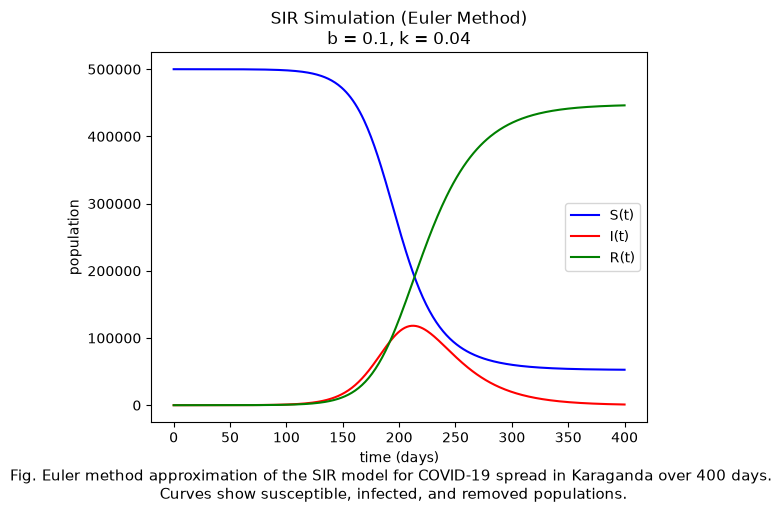

In [2]:
SIR_Euler(0.10,0.04,initial_vals, 400) # lower infection rate

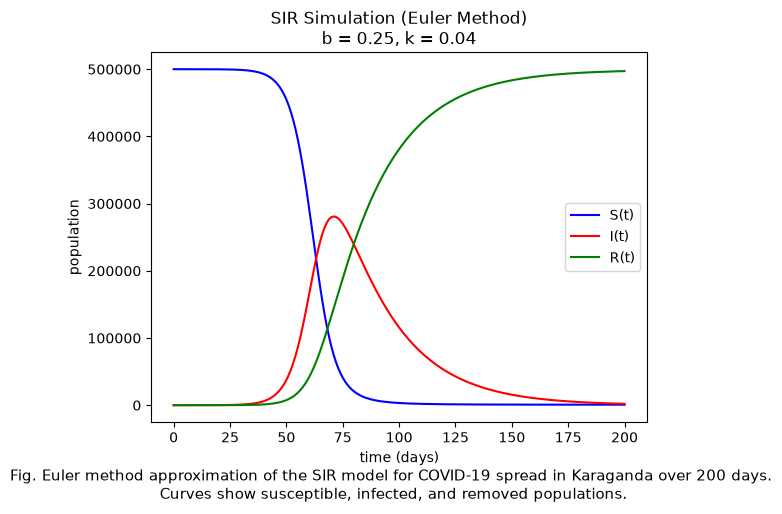

In [3]:
SIR_Euler(0.25,0.04,initial_vals, 200) # higher infection rate

## Varying the removal rate

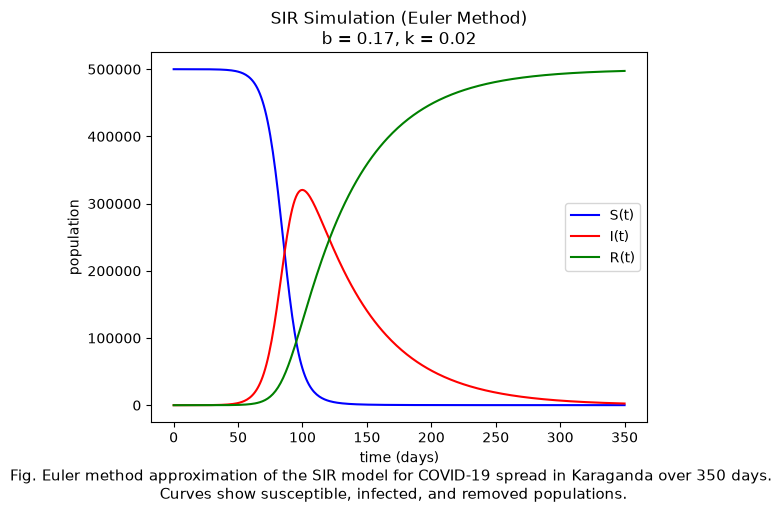

In [4]:
SIR_Euler(0.17,0.02,initial_vals,350) # lower removal rate

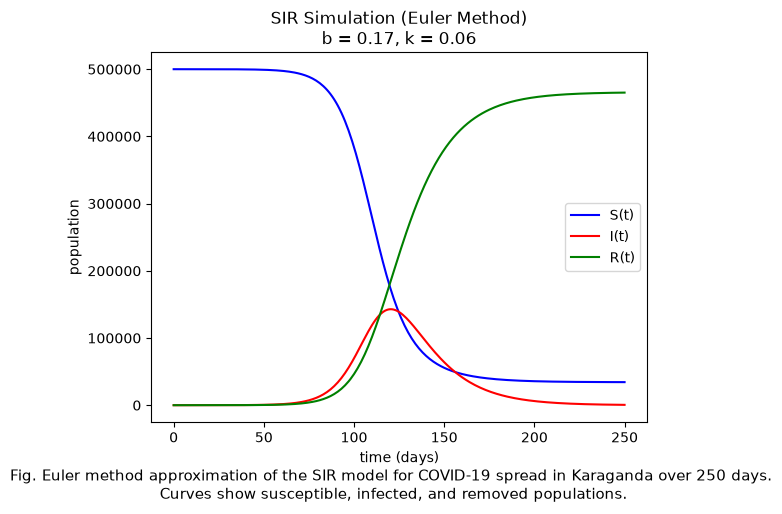

In [5]:
SIR_Euler(0.17,0.06,initial_vals, 250) # higher removal rate